# ***LeNet-5 from Scratch: Analysis on MNIST and CIFAR-10***
<br>

#### This project implements LeNet-5 from scratch in PyTorch using custom-built layers, and analyzes its behavior across two datasets of varying complexity: MNIST and CIFAR-10.
#### The analysis focuses on differences in generalization behavior, the impact of pooling operations, and feature map visualization of patterns learned by convolutional layers.
#### Additionally, misclassified examples are examined to identify common error patterns and highlight weaknesses in the model’s predictions.
<br>

## **Environment Setup and Data Preparation**
#### In this section, I set up the Environment, load the datasets (CIFAR-10 and MNIST), compute basic statistics and apply normalization.

### Environment Setup

In [1]:
%matplotlib inline
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm

from statistics import mean
import numpy as np
import random
import time

### Data Loading & Basic Inspection

In [2]:
def load_cifar(root='../lenet5-from-scratch-analysis/data', transform=transforms.ToTensor()):
    train_set = torchvision.datasets.CIFAR10(root=root, train=True, transform=transform, download=True)
    val_set = torchvision.datasets.CIFAR10(root=root, train=False, transform=transform, download=True)
    return train_set, val_set

In [3]:
def load_mnist(root='../lenet5-from-scratch-analysis/data', transform=transforms.ToTensor()):    
    train_set = torchvision.datasets.MNIST(root=root, train=True, transform=transform, download=True)
    val_set = torchvision.datasets.MNIST(root=root, train=False, transform=transform, download=True)
    return train_set, val_set

In [4]:
train_data, val_data = load_cifar()

In [5]:
train_mnist, val_mnist = load_mnist()

### ***CIFAR-10:***

#### 50k training examples & 10k validation examples

In [6]:
len(train_data), len(val_data)

(50000, 10000)

#### Each sample is in the form (image, label), where the image is a ***3-channel (RGB) 32×32 image***

In [7]:
len(train_data[0]), len(val_data[0])

(2, 2)

In [8]:
train_data[0][0].shape, train_data[0][1], '|', val_data[0][0].shape, val_data[0][1]

(torch.Size([3, 32, 32]), 6, '|', torch.Size([3, 32, 32]), 3)

### ***MNIST:***

#### 60k training examples & 10k validation examples

In [9]:
len(train_mnist), len(val_mnist)

(60000, 10000)

#### Each sample is in the form (image, label), where the image is a ***1-channel (Grayscale) 28×28 image***

In [10]:
len(train_mnist[0]), len(val_mnist[0])

(2, 2)

In [11]:
train_mnist[0][0].shape, train_mnist[0][1], '|', val_mnist[0][0].shape, val_mnist[0][1]

(torch.Size([1, 28, 28]), 5, '|', torch.Size([1, 28, 28]), 7)

### Calculating Basic Statistics and Applying Normalization

#### `Stats_PerChannel` stacks all images from training dataset into a single tensor and calculates:
- #### **min & max** pixel values for each channel to check for potential anomalies  
- #### **mean & std** requiered for normalizing the dataset

In [12]:
def Stats_PerChannel(data, get=False):
    imgs = torch.stack([img for img, _ in data])
    
    min_vals = imgs.amin(dim=(0, 2, 3))
    max_vals = imgs.amax(dim=(0, 2, 3))
    print(f"Min vals: {min_vals}\tMax vals: {max_vals}\n")
    
    means = torch.mean(imgs, dim=(0, 2, 3))
    stds = torch.std(imgs, dim=(0, 2, 3))
    print(f"Mean: {means}\tStd: {stds}")

    if get:
        m = tuple(round(x, 5) for x in means.tolist())
        s = tuple(round(x, 5) for x in stds.tolist())
        return m, s

### ***CIFAR-10:***

#### Pixel values are within the expected range - *[0, 1]*

In [13]:
norm_mean, norm_std = Stats_PerChannel(train_data, get=True)

Min vals: tensor([0., 0., 0.])	Max vals: tensor([1., 1., 1.])

Mean: tensor([0.4914, 0.4822, 0.4465])	Std: tensor([0.2470, 0.2435, 0.2616])


In [14]:
norm_mean, norm_std

((0.4914, 0.48216, 0.44653), (0.24703, 0.24349, 0.26159))

#### CIFAR-10 dataset is reloaded with normalization applied using the computed mean and std

In [15]:
train_data, val_data = load_cifar(transform=transforms.Compose([transforms.ToTensor(),
     transforms.Normalize(norm_mean, norm_std)]))

#### After normalization, pixel values have mean ≈ 0 and standard deviation = 1 across all channels.</p> This ensures that no feature will dominate due to scale differences

In [16]:
Stats_PerChannel(train_data)

Min vals: tensor([-1.9892, -1.9802, -1.7070])	Max vals: tensor([2.0589, 2.1267, 2.1158])

Mean: tensor([-1.2720e-06, -6.4988e-06,  3.4809e-06])	Std: tensor([1.0000, 1.0000, 1.0000])


### ***MNIST:***

#### Pixel values are within the expected range - *[0, 1]*

In [17]:
mnist_mean, mnist_std = Stats_PerChannel(train_mnist, get=True)

Min vals: tensor([0.])	Max vals: tensor([1.])

Mean: tensor([0.1307])	Std: tensor([0.3081])


In [18]:
mnist_mean, mnist_std

((0.13066,), (0.30811,))

#### Since LeNet-5 takes 32x32 inputs, MNIST images are reshaped and normalzied with the computed mean and std 

In [19]:
train_mnist, val_mnist = load_mnist(transform=transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)]))

#### Since MNIST images are mostly composed of a black background, the value range may not be perfectly symmetric 
#### After normalization, pixel values have mean ≈ 0 and standard deviation ≈ 1

In [20]:
Stats_PerChannel(train_mnist)

Min vals: tensor([-0.4241])	Max vals: tensor([2.8215])

Mean: tensor([0.0008])	Std: tensor([0.9389])


## **Dataset Visualization**

### Visualization Helper Functions

In [21]:
def define_labels(set_name):
    if set_name == 'mnist':
        return {i: i for i in range(0, 10)}
    else:
        return {0: 'plane', 1: 'car', 2: 'bird', 3: 'cat', 4: 'deer', 
           5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

#### Since both datasets are normalized, `imshow` denormalizes the images before visualization

In [22]:
def imshow(img, lbl, m, s):
    mean, std = torch.tensor(m), torch.tensor(s)
    img = img * std[:, None, None] + mean[:, None, None]   
    img.clamp_(0, 1)
    
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(lbl)

#### `viz_random` visualizes 20 random images from the given dataset

In [23]:
def viz_random(data, set_name, m, s):
    rand_idx = random.sample(range(0, len(data)), 20)
    classes = define_labels(set_name)
    
    figure = plt.figure(figsize=(12, 3), tight_layout=True)

    for i, idx  in enumerate(rand_idx):
        img, label = data[idx]
        figure.add_subplot(2, 10, i+1)
        imshow(img, classes[label], m, s)
    plt.show()

### ***CIFAR-10:***

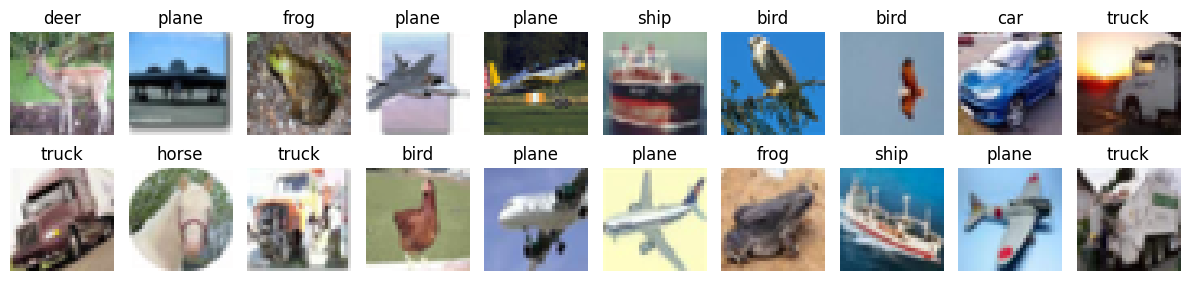

In [24]:
viz_random(train_data, 'cifar', norm_mean, norm_std)

### ***MNIST:***

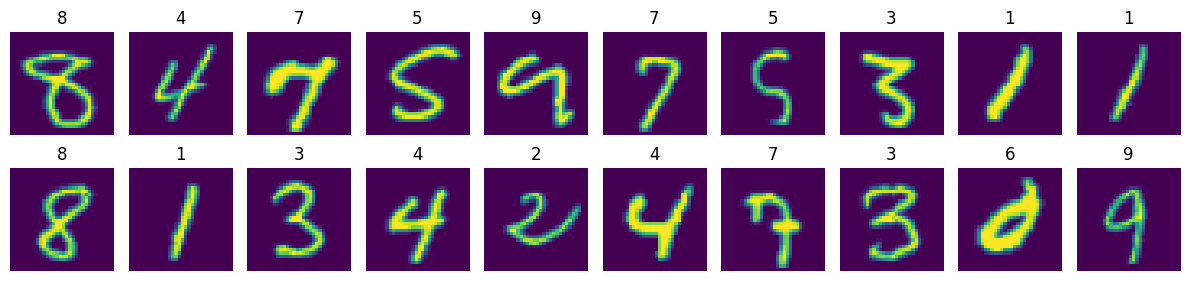

In [25]:
viz_random(train_mnist, 'mnist', mnist_mean, mnist_std)

#### **Key Differences:**
#### The main technical difference, besides obvious class complexity, is that CIFAR-10 consists of 3-channel RGB images, while MNIST is single-channel (grayscale). Taken together, these factors suggest that LeNet-5 is likely to achieve substantially lower accuracy on CIFAR-10.
#### It is worth noting that, despite MNIST being a grayscale dataset, MatPlotLib's default colormap maps pixel intensities to a color scale for better visibility.
<br>

## **Architecture**
#### In this section, I implement the LeNet-5 architecture from scratch by defining dedicated classes for each fundamental building block, such as convolutional, pooling, and linear layers.
#### This modular approach allows the final model to be simply constructed by instantiating these classes for each specific operation. (similar to the layer-based instantiation in the PyTorch API).

<center>
  <img src="figures/LeNet-5_Figure.png" width="800" style="margin-top: 30px;">
</center>
<p style="margin-bottom: 30px;">
Original LeNet-5 architecture (LeCun et al., 1998).
</p>

### My implementation follows the overall structure of the original LeNet-5 architecture:
- #### ***Layer 1:***  5x5 convolution layer with 6 filters, followed by ReLU
- #### ***Layer 2:***  2x2 non-trainable pooling layer (stride 2, non-trainable)
- #### ***Layer 3:***  5x5 convolution layer with 16 filters, followed by ReLU
- #### ***Layer 4:***  2x2 pooling layer (stride 2, non-trainable)
- #### ***Layer 5:***  Linear layer with 120 hidden units
- #### ***Layer 6:***  Linear layer with 84 hidden units
- #### ***Layer 7:***  Linear layer with 10 output units
 <br>

### ***Convolution layer class***

#### Since LeNet-5 does not use padding and stride above 1 in any convolutional layer, output shape is given by the simple formula:
- #### **Number of filters, (Input height - Kernel height + 1), (Input width - Kernel width + 1)**

#### The convolutional kernels are initialized using *He Kaiming Initialization* technique, which accounts for the "halving" effect of ReLU

#### The forward pass computes the output using a *vectorized sliding-window approach*

In [26]:
class ConvLayer(nn.Module):
    def __init__(self, k_size, num_in, num_out, device):
        super().__init__()
        self.K_h, self.K_w = k_size
        self.K_c = num_out
        self.device = device
        
        """ He Kaiming Initialization """
        fan_in = num_in * self.K_h * self.K_w
        std = np.sqrt(2.0 / fan_in)

        """ Defining Parameters """
        self.K = torch.nn.Parameter(
            torch.randn(self.K_c, num_in, self.K_h, self.K_w) * std)
        
        self.b = torch.nn.Parameter(torch.zeros(num_out, 1, 1))

    def forward(self, X):
        X_batch, X_h, X_w = X.shape[0], X.shape[2], X.shape[3]
        Y = torch.zeros(X_batch, self.K_c, X_h - self.K_h + 1, X_w - self.K_w + 1, device=self.device)
        
        for i in range(Y.shape[2]):
            for j in range(Y.shape[3]):
                x_slice = X[:, :, i: i+self.K_h, j: j+self.K_w]         
                Y[:, :, i, j] = (x_slice.unsqueeze(dim=1) * self.K).sum(dim=(2, 3, 4))
                
        return Y + self.b 

### ***Pooling Layer Class***

#### The pooling layer performs spatial downsampling using either **average** or **max pooling**

#### The output shape is determined by the kernel size and stride:
- #### **Number of channels, (Input height - Kernel height) // stride + 1, (Input width - Kernel width) // stride + 1**

#### The forward pass applies the selected pooling operation over sliding windows across the input

In [27]:
class PoolLayer(nn.Module):
    def __init__(self, k_size, stride, p_type, device):
        super().__init__()
        self.K_h, self.K_w = k_size
        self.stride = stride
        self.device = device
        
        """ Setting Pooling function """
        if p_type == 'avg':
            self.func = torch.mean
        else:
            self.func = torch.amax

    def forward(self, X):
        X_batch, X_c, X_h, X_w = X.shape[0], X.shape[1], X.shape[2], X.shape[3]
        Y = torch.zeros(X_batch, X_c, (X_h - self.K_h)//self.stride + 1,
                        (X_w - self.K_w)//self.stride + 1, device=self.device)

        for i, i_x in enumerate(range(0, X_h - self.K_h + 1, self.stride)):
            for j, j_x in enumerate(range(0, X_w - self.K_w + 1, self.stride)):
                x_slice = X[:, :, i_x: i_x + self.K_h, j_x: j_x + self.K_w]
                Y[:, :, i, j] = self.func(x_slice, dim=(2, 3))
                
        return Y

### ***Linear Layer Class***

#### The linear layer performs a fully connected transformation on the previously flattened input

#### Similarly to the convolution layer, weights are initialized using *He Kaiming initialization*

#### The forward pass computes a linear transformation using matrix multiplication, adding a bias vector 

In [28]:
class LinearLayer(nn.Module):
    def __init__(self, num_in, num_out):
        super().__init__()

        """ He Kaiming Initialization """
        std = np.sqrt(2.0 / num_in)

        """ Defining Parameters """
        self.W = torch.nn.Parameter(torch.randn(num_in, num_out) * std)
        self.b = torch.nn.Parameter(torch.zeros(num_out))

    def forward(self, X):
        return torch.matmul(X, self.W) + self.b

### ***LeNet-5 Model Class***

#### This class combines the previously defined layers to form the full LeNet-5-based architecture

#### The forward pass applies convolution and pooling blocks with ReLU activations, followed by flattening and fully connected layers

#### Cross-Entropy loss computes the Softmax and Negative Log Likelihood on the logits returned by the final linear layer

#### Stochastic Gradient Descent updates the model parameters using gradients computed during backpropagation, which is handled by the Trainer class

#### The batch step combines the forward pass, loss computation, and accuracy calculation into a single function, simplifying its use within the Trainer Class

In [29]:
class LeNet_5(nn.Module):
    def __init__(self, lr, device, in_channels=3, p_type='avg'):
        super().__init__()
        self.lr = lr
        self.device = device
        self.p_type = p_type

        self.Conv_1 = ConvLayer(k_size=(5, 5), num_in=in_channels, num_out=6, device=self.device)
        self.Pool_1 = PoolLayer(k_size=(2, 2), stride=2, p_type=self.p_type, device=self.device)
        self.Conv_2 = ConvLayer(k_size=(5, 5), num_in=6, num_out=16, device=self.device)
        self.Pool_2 = PoolLayer(k_size=(2, 2), stride=2, p_type=self.p_type, device=self.device)
        
        self.Linear_1 = LinearLayer(num_in=400, num_out=120)
        self.Linear_2 = LinearLayer(num_in=120, num_out=84)
        self.Linear_3 = LinearLayer(num_in=84, num_out=10)

    def forward(self, X):
        X = self.Pool_1(F.relu(self.Conv_1(X)))
        X = self.Pool_2(F.relu(self.Conv_2(X)))
        X = X.reshape(X.shape[0], -1)
        X = F.relu(self.Linear_2(F.relu(self.Linear_1(X))))
        return self.Linear_3(X)

    def ce_loss(self, Y_hat, Y):
        return F.cross_entropy(Y_hat, Y, reduction='mean')

    def config_optim(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)
        
    def batch_step(self, batch):
        X, y = batch
        X, y = X.to(self.device), y.to(self.device)
        
        Y_hat = self.forward(X)
        l = self.ce_loss(Y_hat, y)
        acc = (Y_hat.argmax(dim=1) == y).float().mean()
        return l, acc.item()

## ***Training Pipeline***
#### In this section, I define the training pipeline, which handles the training/validation process, data batching and loss/accuracy plotting
<br>

### ***Data Loader***

#### Simple data loader, handling train and validation batching with a specified batch size 

In [30]:
def data_loader(data, is_train, batch_size):
    return torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=is_train, num_workers=2)

### ***Trainer Class***

#### Handles the training loop, including data preparation, plotter initalization, forward and backward passes, and validation

#### Due to relatively long training time caused by the by the from-scratch implementation, progress bars are used to monitor training and validation performance

In [31]:
class Trainer():
    def __init__(self, num_epochs, batch_size):
        self.num_epochs = num_epochs
        self.batch_size = batch_size

    def plotter_init(self, title):
        self.plotter = Plotter(title)

    def prepare_data(self, train_data, val_data):
        self.train_dataloader = data_loader(train_data, True, self.batch_size)
        self.val_dataloader = data_loader(val_data, False, self.batch_size)
  
    def fit(self, model, train_data, val_data):
        self.prepare_data(train_data, val_data) 
        self.model = model
        self.optim = model.config_optim()
        
        for epoch in range(self.num_epochs):
            self.fit_epoch(epoch+1)

    def fit_epoch(self, n_epoch):
        train_loss, val_loss, val_acc = [], [], []
        self.model.train()
        pbar_train = tqdm(self.train_dataloader, desc=f"Epoch: {n_epoch} [Train]", leave=True)
        
        for batch in pbar_train:
            loss, _ = self.model.batch_step(batch)     
            self.optim.zero_grad()
            loss.backward()
            self.optim.step()
            
            train_loss.append(loss.item())
            pbar_train.set_postfix(loss=f"{loss.item():.4f}")
            
        self.model.eval()
        pbar_val = tqdm(self.val_dataloader, desc=f"Epoch: {n_epoch} [Val]", leave=True)
        
        for batch in pbar_val:
            with torch.no_grad():
                loss, acc = self.model.batch_step(batch)
                
                val_loss.append(loss.item())
                val_acc.append(acc)
                pbar_val.set_postfix(acc=f"{acc:.2f}")
                
        self.plotter.plot(mean(train_loss), mean(val_loss), mean(val_acc))

### ***Plotter Class***

#### Stores training loss, validation loss, and validation accuracy for each epoch and visualizes them using Matplotlib

In [32]:
class Plotter():
    def __init__(self, title):
        self.title = title
        self.train_losses = []
        self.val_losses = []
        self.val_acc = []
        self.epoch = 0

    def update_stats(self, train_loss, val_loss, acc):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.val_acc.append(acc)
        self.epoch += 1

    def plot(self, train_loss, val_loss, acc):
        self.update_stats(train_loss, val_loss, acc)
        epochs = range(1, self.epoch + 1)
        
        clear_output(wait=True) 
        plt.figure(figsize=(6,4), constrained_layout=True)
        plt.plot(epochs, self.train_losses, label=f"Train loss: {self.train_losses[-1]:.4f}")
        plt.plot(epochs, self.val_losses, label=f"Val loss: {self.val_losses[-1]:.4f}")
        plt.plot(epochs, self.val_acc, linestyle="-.", label=f"Val acc: {self.val_acc[-1]:.4f}")
        plt.xlabel("Epoch")
        plt.title(self.title)
        plt.legend()
        plt.show()

## ***Training the Model***

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### ***CIFAR-10:***
<br>

#### *Average pooling:*

In [82]:
model_cifar1 = LeNet_5(lr=0.1, device=device, in_channels=3, p_type='avg')
model_cifar1.to('cuda')

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

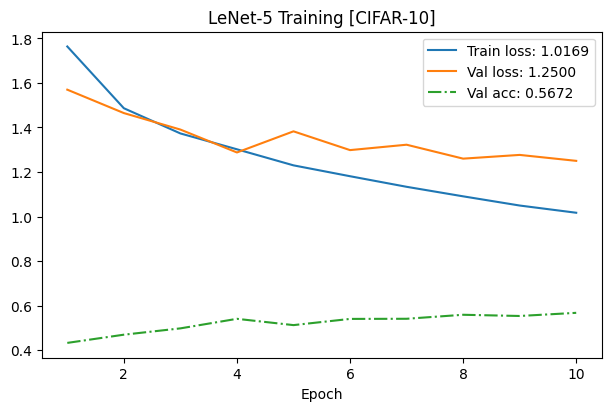

In [83]:
trainer_cifar1 = Trainer(num_epochs=10, batch_size=128)
trainer_cifar1.plotter_init("LeNet-5 Training [CIFAR-10]")
trainer_cifar1.fit(model_cifar1, train_data, val_data)

#### The training loss decreases steadily, while validation loss highly increased after 4th epoch, suggesting that the model is fitting the training data more closely, which may indicate overfitting.
#### It is worth noting that LeNet-5 was primarily designed for the MNIST dataset, which is much less complicated compared to the CIFAR-10.
#### This suggests that relatively low accuracy ***(~0.57)*** is close to the performance limit of LeNet-5, due to its limited capacity.
#### The generalization gap between training and validation loss indicates limited model generalization, likely caused by the lack of regularization techniques, such as dropout, which is commonly used in convolutional neural networks with fully connected layers.
<br>

#### *Max pooling:*

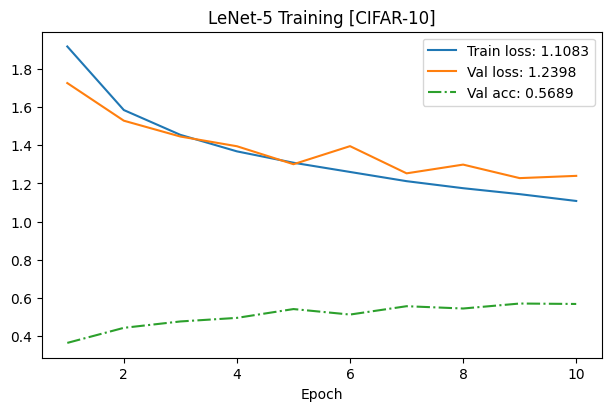

In [84]:
model_cifar2 = LeNet_5(lr=0.1, device=device, in_channels=3, p_type='max')
model_cifar2.to('cuda')
trainer_cifar2 = Trainer(num_epochs=10, batch_size=128)
trainer_cifar2.plotter_init("LeNet-5 Training [CIFAR-10]")
trainer_cifar2.fit(model_cifar2, train_data, val_data)

#### Despite changing the pooling operation, there is little difference in accuracy compared to the previous model. This suggests that the main bottleneck is **the architecture's limited capacity**.
#### Furthermore, the model is likely **too narrow** to effectively learn complex spatial features in 3-channel (RGB) CIFAR-10 images.
#### Upon closer inspection, it can be seen that the generalization gap is noticeably **narrower** compared to the previous model, decreasing from approximately **0.23 to 0.13**.
#### This suggests that max pooling may provide slightly better **regularization** than average pooling for LeNet-5 on CIFAR-10.
<br>

### ***MNIST:***
<br>

#### *Average pooling:*

In [29]:
model_2 = LeNet_5(lr=0.1, device=device, in_channels=1)
model_2.to(device)

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

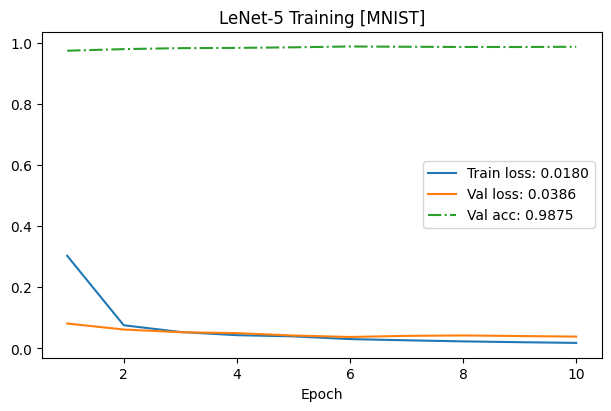

In [30]:
trainer = Trainer(num_epochs=10, batch_size=128)
trainer.plotter_init("LeNet-5 Training [MNIST]")
trainer.fit(model_2, train_mnist, val_mnist)

#### It can be clearly seen that MNIST's much lower complexity (1-channel grayscale images) leads to substantially increased accuracy compared to CIFAR-10.
#### The model converges very quickly, reaching **near-optimal** performance within the first few epochs.
#### After just one epoch, the model is able to achieve ***~0.95*** accuracy, highlighting that LeNet-5 was originally designed for this type of data.
#### Upon closer inspection, it is clear that validation loss stabilizes while training loss continues to decrease, leading to a widening generalization gap. This suggests that further training provides minimal benefit and may even lead to overfitting or lower accuracy.
#### The training process is stable, with both validation loss and accuracy showing minimal fluctuations.
<br>

#### *Max pooling:*

In [76]:
model_3 = LeNet_5(lr=0.1, device=device, in_channels=1, p_type='max')
model_3.to(device)

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

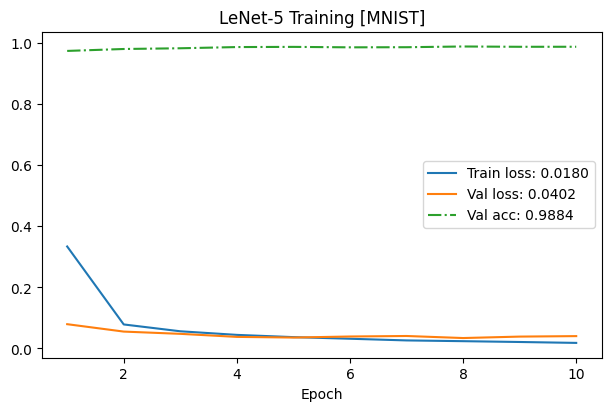

In [77]:
trainer_3 = Trainer(num_epochs=10, batch_size=128)
trainer_3.plotter_init("LeNet-5 Training [MNIST]")
trainer_3.fit(model_3, train_mnist, val_mnist)

#### Despite changing the pooling operation, there is little difference in accuracy compared to the previous model. This suggests that the model may have reached in its capacity to learn spatial features.
#### Additionally, max pooling does not significantly affect generalization gap or validation loss.
#### However, upon closer inspection, during the first 8 epochs the validation loss is slightly lower compared to the previous model.
#### The training process remains stable, with only minor differences compared to the previous model.
<br>

## ***Feature Map Visualization***
#### This section focuses on visualizing convolutional feature maps to better understand how each layer learns spatial features.
<br>

### Feature Maps Visualization Helper Functions

#### Basic image visualization function  

In [139]:
def mapshow(img, lbl):
    img = (img - img.min()) / (img.max() - img.min() + 1e-5)
    
    plt.imshow(img)
    plt.axis("off")
    plt.title(lbl)

#### `viz_Conv1` extracts feature maps from the first convolutional layer and displays them for different classes and filters.

In [137]:
def viz_Conv1(batch, model, set_name):
    X_data, y_data = batch
    dist_lbl, dist_idx = np.unique(y_data, return_index=True)
    classes = define_labels(set_name)
    
    figure = plt.figure(figsize=(12, 9), tight_layout=True)

    with torch.no_grad():
        layer = model.Conv_1
        layer_out = layer.forward(X_data.to('cuda')).to('cpu')
        
        for c in range(layer.K_c):
            for i, (label, idx) in enumerate(zip(dist_lbl, dist_idx)):
                img = layer_out[idx, c]
                figure.add_subplot(6, 10, (i+1)+10*c)
                title = str(classes[label])             
                if label == dist_lbl[0]:
                    title = f"[Filter: {c+1}]  {title}"
                
                mapshow(img, title)
    plt.show()

#### `viz_Conv2` extracts feature maps from the second convolutional layer by passing the input through the preceding layers and displays them across different classes and filters.

In [141]:
def viz_Conv2(batch, model, set_name):
    X_data, y_data = batch
    dist_lbl, dist_idx = np.unique(y_data, return_index=True)
    classes = define_labels(set_name)
    
    figure = plt.figure(figsize=(12, 9), tight_layout=True)

    with torch.no_grad():
        layer = model.Conv_2
        layer_in = model.Pool_1.forward(model.Conv_1.forward(X_data.to('cuda')))
        layer_out = layer.forward(layer_in).to('cpu')
        
        for idc, c in enumerate(range(0, layer.K_c, 3)):
            for i, (label, idx) in enumerate(zip(dist_lbl, dist_idx)):
                img = layer_out[idx, c]
                figure.add_subplot(6, 10, (i+1)+10*idc)
                title = str(classes[label])
                if label == dist_lbl[0]:
                    title = f"[Filter: {c+1}]  {title}"
                
                mapshow(img, title)
    plt.show()

### ***CIFAR-10:***
<br>

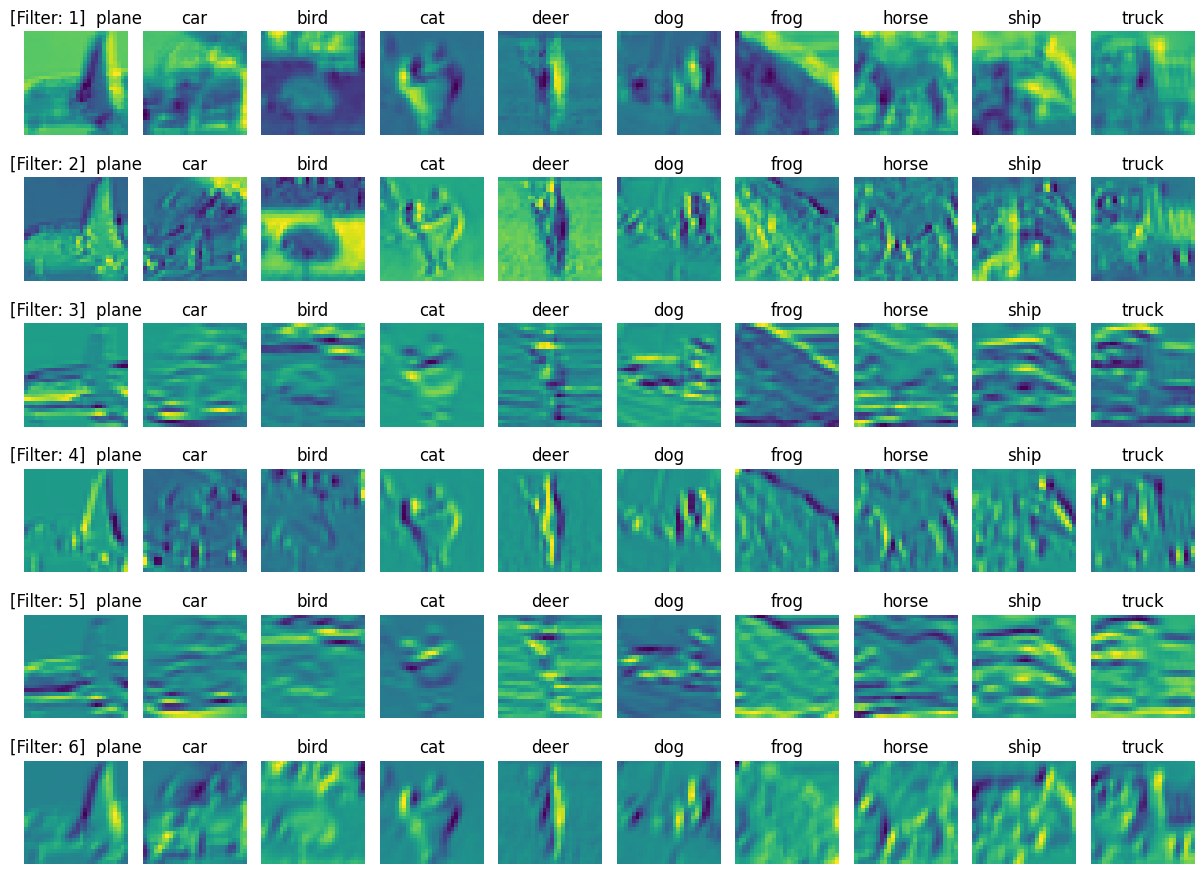

In [144]:
viz_Conv1(next(iter(data_loader(train_data, True, 64))), model_cifar1, 'cifar')

#### The first convolutional layer captures basic spatial patterns, with different filters responding to various regions and structures in the input images.
#### The similarity of images within each filter highlights the filters consistent ability to distinguish specific features across different inputs.
<br>

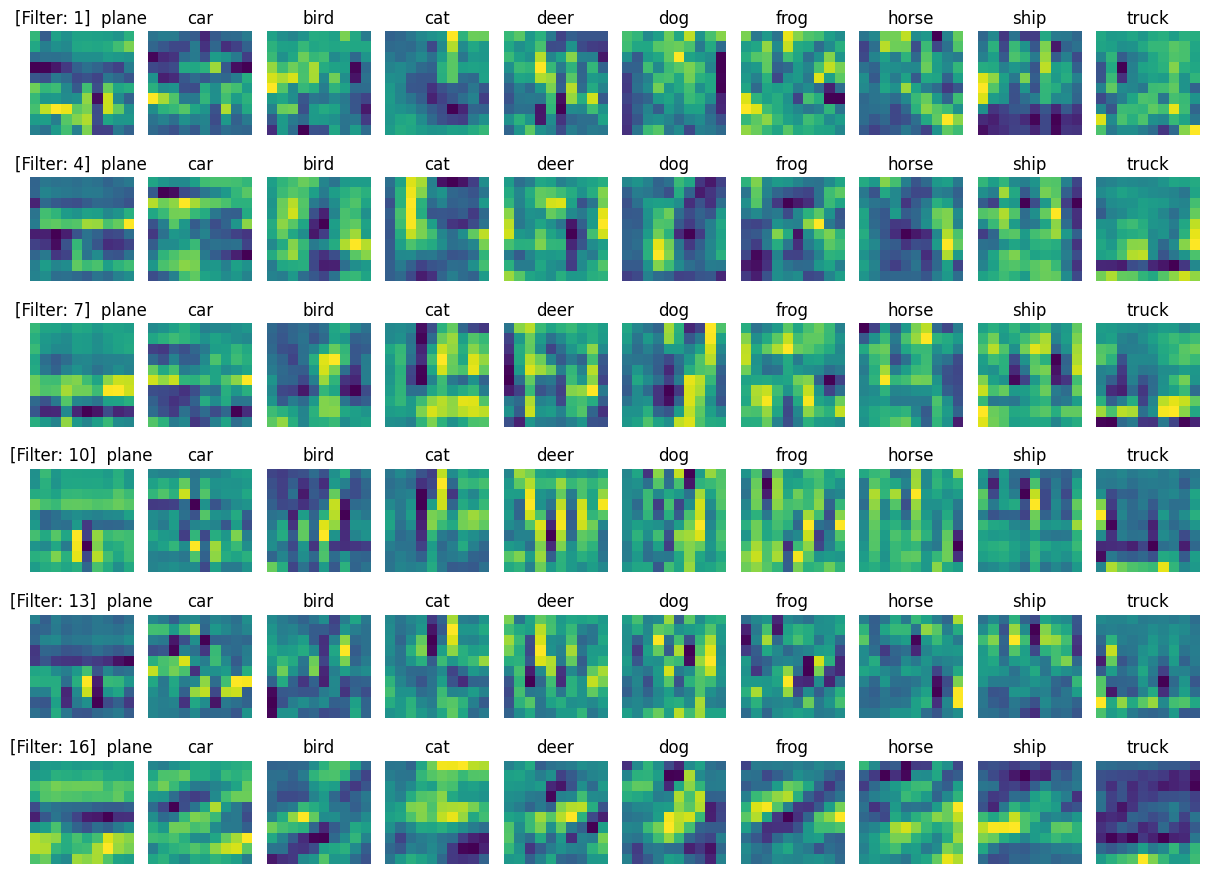

In [145]:
viz_Conv2(next(iter(data_loader(train_data, True, 64))), model_cifar1, 'cifar')

#### Filters capture more complex combinations of simpler patterns, resulting in less visually interpretable representations.
#### However, different filters still appear to highlight specific features, such as vertical patterns in filter 10 and diagonal patterns in filter 16.
<br>

### ***MNIST:***
<br>

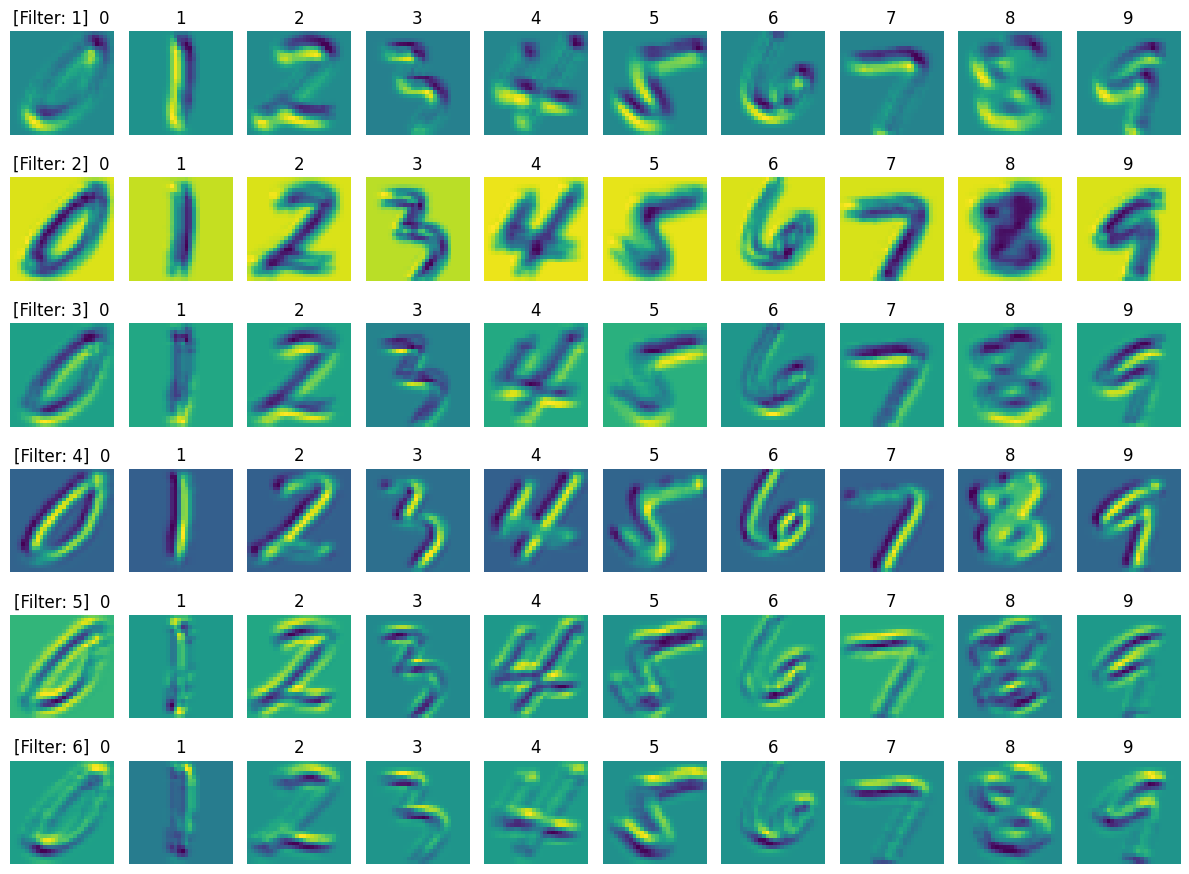

In [140]:
viz_Conv1(next(iter(data_loader(train_mnist, True, 64))), model_2, 'mnist')

#### The MNIST's images simplicity makes feature maps more interpretable:
- #### **Filter 2** appears to strongly respond to the background, possibly highlighting differences in pixel intensity.
- #### **Filter 3** appears to highlight upper edge-like structures in the digits.
- #### **Filter 4** appears to highlight left-side edge-like patterns in the digits.
<br>

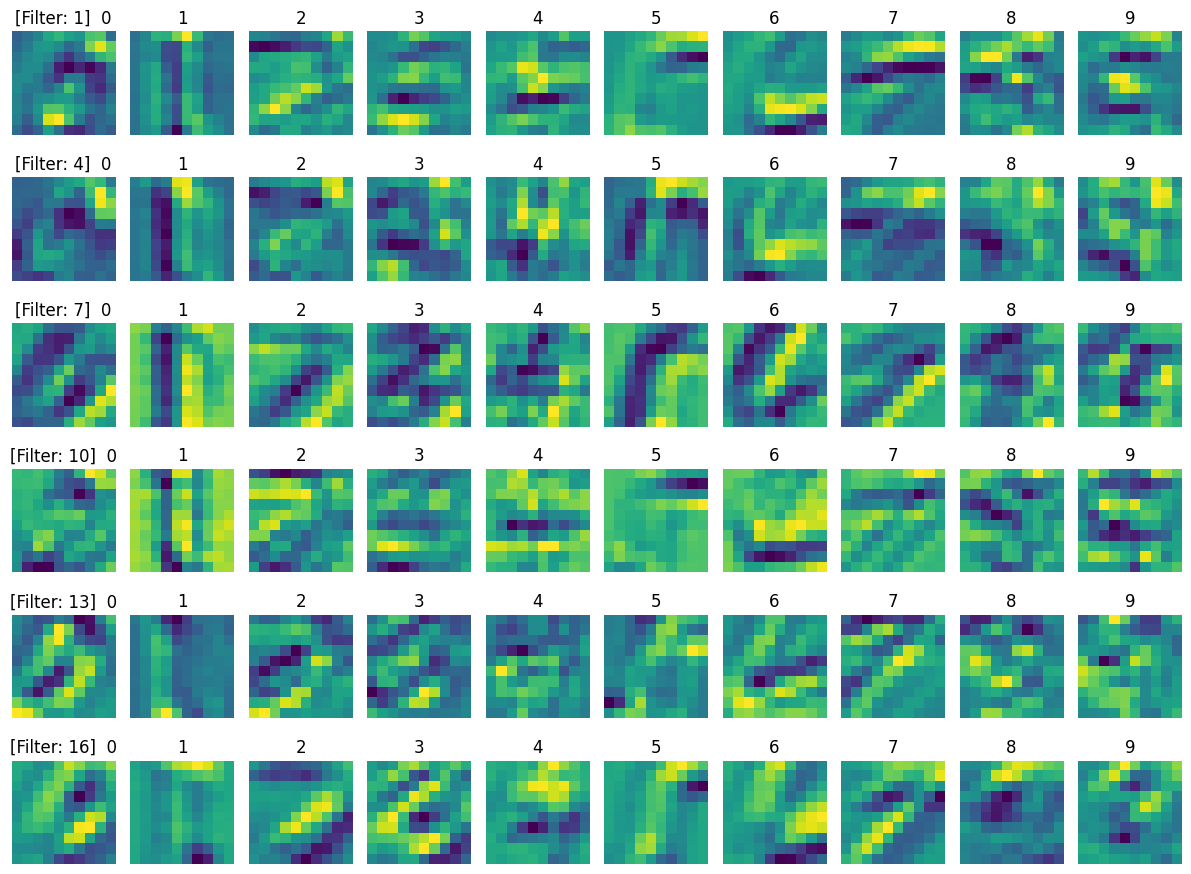

In [143]:
viz_Conv2(next(iter(data_loader(train_mnist, True, 64))), model_2, 'mnist')

#### Filters capture more complex combinations of simpler patterns, resulting in less visually interpretable representations.
#### Some filters still appear to respond to consistent patterns across different digits.
<br>

## ***Misclassified Examples***
#### In this section, I analyze misclassified examples from the first and second convolutional layer to better understand models limitations and common failure cases.
<br>

#### `false_predic` extracts incorrectly predicted samples and displays them with their predicted labels.

In [35]:
def false_predic(batch, model, m, s, set_name='cifar'):
    X_data, y_data = batch
    classes = define_labels(set_name)

    figure = plt.figure(figsize=(12, 9), tight_layout=True)
    
    with torch.no_grad():
        model_output = model.forward(X_data.to('cuda'))
        predic_lbls = torch.argmax(model_output, dim=1).to('cpu')
        X_data.to('cpu')
        idx = 0
        for img, y, y_hat in zip(X_data, y_data, predic_lbls):
            if y_hat != y:
                idx += 1
                figure.add_subplot(6, 10, idx)
                title = f"Pred:   {classes[y_hat.item()]}"
                imshow(img, title, m, s)
    plt.show()

### ***CIFAR-10 (max pooling):***
<br>

In [36]:
model_cifarMax = LeNet_5(lr=0.1, device=device, in_channels=3, p_type='max')
model_cifarMax.load_state_dict(torch.load("lenet_cifar2.pth"))
model_cifarMax.to(device)
model_cifarMax.eval()

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

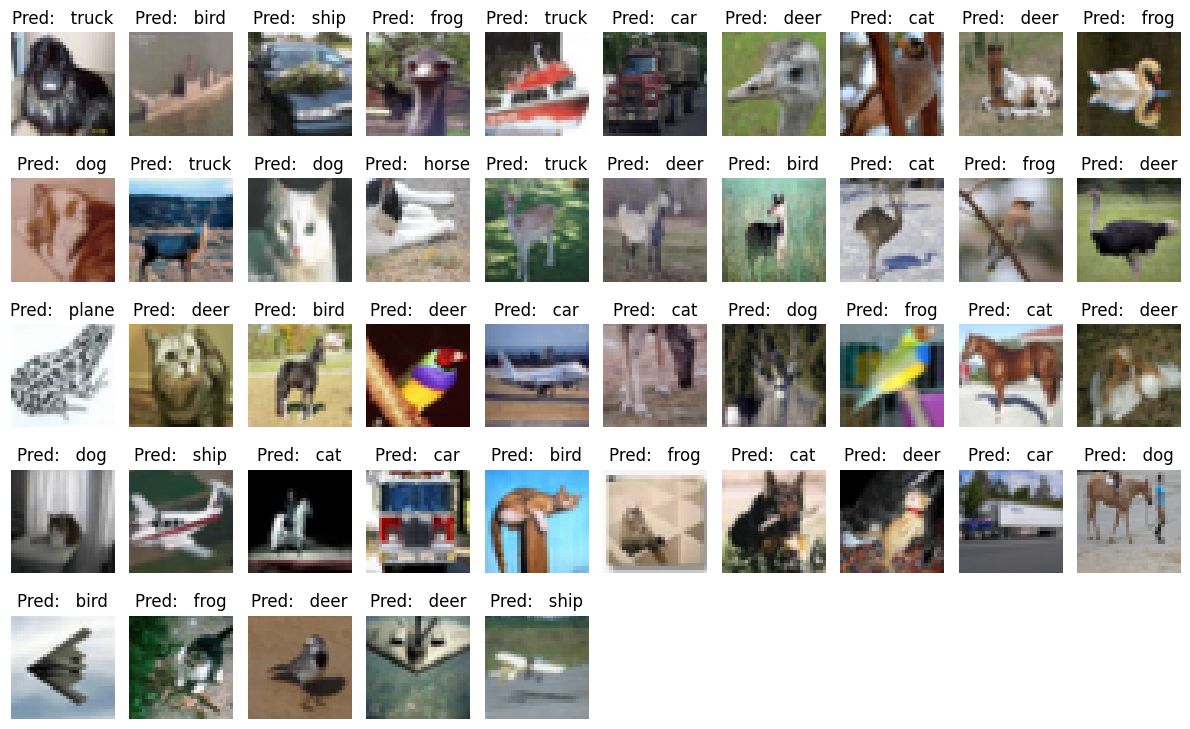

In [61]:
false_predic(next(iter(data_loader(train_data, True, 128))), model_cifarMax, norm_mean, norm_std)

#### It is clear that the model often confuses visually similar classes, such as cats and dogs, deer and horses or cars and trucks.
#### Moreover, the model struggles with classes that share similar background characteristics, such as birds and planes and cars and trucks.
#### Many misclassifications occur when the background is more characteristic of another class, e.g. a cat with sky behind it being mistaken for a bird, or an ostrich (bird) mistaken for a deer.
#### Some errors may also be caused by low-resolution images, where important distinguishing features are not clearly visible.

### ***MNIST (max pooling):***
<br>

In [34]:
model_mnistMax = LeNet_5(lr=0.1, device=device, in_channels=1, p_type='max')
model_mnistMax.load_state_dict(torch.load("lenet_mnist2.pth"))
model_mnistMax.to(device)
model_mnistMax.eval()

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

#### Since LeNet-5 max pooling achieved ***~0.99*** accuracy, the batch size was increased (5000) to better observe misclassification patterns.

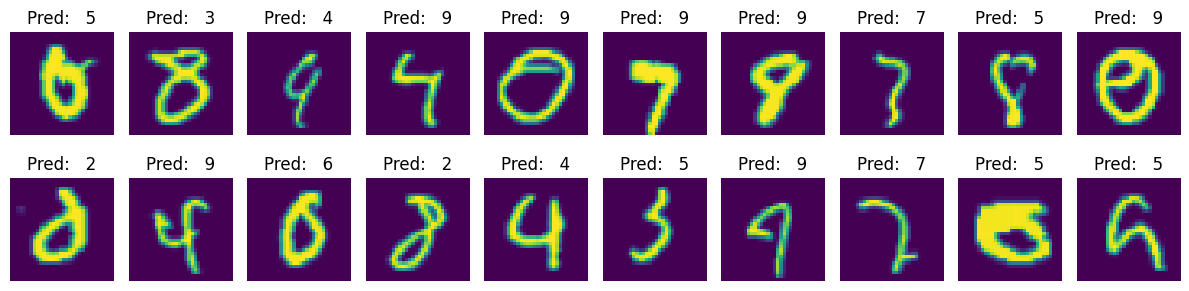

In [42]:
false_predic(next(iter(data_loader(train_mnist, True, 5000))), model_mnistMax, mnist_mean, mnist_std, 'mnist')

#### A significant portion of misclassified digits appear ambiguous or poorly written, making them extremely difficult to interpret even for humans.
#### Upon further inspection, the model shows difficulty in classifying certain digits, particularly 8, which may indicate challenges in capturing more complex, rounded structures.
#### Additionally, some samples appear to be incorrectly labeled, suggesting the presence of label noise in the dataset.
<br>

## **Conclusions**

- #### LeNet-5 performs exceptionally well on the MNIST dataset, achieving near-perfect ***~0.99*** accuracy and converging rapidly within the first few epochs.
- #### On the other hand, LeNet-5 struggles significantly on the CIFAR-10 (***~0.57*** accuracy), suggesting that its limited capacity is insufficient for learning complex features in 3-channel CIFAR-10 images.
- #### The difference in accuracy between both datasets highlights that LeNet-5 was originally designed for 1-channel (grayscale) data.

- #### Max pooling has minimal impact on accuracy compared to average pooling:
  - #### **CIFAR-10:** Max pooling narrows the generalization gap compared to average pooling, reducing it from roughly **0.23 to 0.13**.
  - #### **MNIST:** Max pooling slightly lowers the validation loss during **the first 8 epochs**, bringing it slightly closer to the training loss.

- #### Feature map visualization highlights the filters' consistent ability to distinguish specific features across different inputs, resulting in similar responses within **each filter**, especially visible on the MNIST dataset.

- #### The misclassified examples reveal distinct patterns across each dataset:
  - #### **CIFAR-10:** The model struggles with **visually similar** classes (e.g., cats/dogs, cars/trucks) and classes that share similar **background characteristics**, such as birds and planes appearing against blue sky.
  - #### **MNIST:** A significant portion of errors occur on **ambiguous** or poorly written digits. Additionally, the model shows difficulty with more complex, rounded structures (e.g., the digit 8), as well as instances of possible **label noise** within the dataset.
<br>
<br>

## **References**
 - **MNIST:** Yann LeCun et al., *Gradient-based learning applied to document recognition*, 1998.
 - **LeNet-5**: Yann LeCun et al., *Gradient-based learning applied to document recognition*, 1998.
 - **CIFAR-10:** Alex Krizhevsky, *Learning Multiple Layers of Features from Tiny Images*, 2009.